# Modeling Logistic Growth: part 2

We will re-elaborate the results obtained in the previous parts, by performing additional experiments in order to gain more insights on the model and how UDE behaves with it.

In [102]:
# modules
from torch import nn
import torch 
import pysindy as ps
from sr3_modified import my_SR3 as SR3
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt 
from torchdiffeq import odeint
from scipy.integrate import quad
import matplotlib as mpl 

In [2]:
# define the model same as before
k = 6
rho0 = 1
rho = np.array(
    [0, 0.25, 0.1, 0.001, 1]
)

def generalised_growth(t, data, k, rho):
    x = data[0]
    powers = np.arange(1, k)
    x_pow = np.power(x, powers)

    return np.array(
        [rho0 * x * (1 - np.dot(x_pow, rho)) ]
    )


In [3]:
# helper function for polynomial definition

def poly_sindy(x, deg: int, model: ps.SINDy):
    # evaluates a polynomial of degree deg with trained SINDy model's coefficient
    p = np.zeros(deg)
    p[1:] = model.coefficients()

    p = p[::-1]

    return np.polyval(p, x)

def poly_real(x, deg):
    p = np.zeros(deg)

    p[1] = 1

    p[2:] = -rho0 * rho.reshape(deg-2)

    p = p[::-1]

    return np.polyval(p, x)


## Step 0: extremal cases

We will see the cases where we choose extremal initial points for the UDE to simulate, that is $x_0 = 0.01$ and $x_0 = 2$

### $x_0 = 0.01$

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


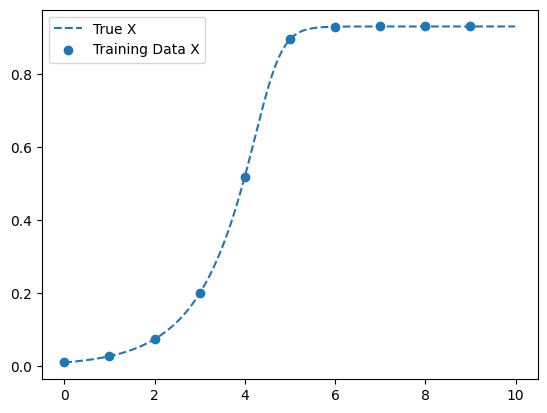

In [216]:
T_MAX = 10.

x0 = 0.01

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")


T_train = T[::100]
X_train = X[::100]


print(T_train)
plt.scatter(T_train, X_train, label="Training Data X")


plt.legend()

plt.show()

In [217]:
model_old = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=5000, verbose=True)
)
model_old.fit(X_train, T_train, feature_names=['x'])

model_old.print()

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.2849e-02 ... 0.0000e+00 ... 3.0000e-02 ... 6.2849e-02
         1 ... 1.9868e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.9868e-02
         2 ... 1.8072e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.8072e-02
         3 ... 1.6788e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.6788e-02
         4 ... 1.5854e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.5854e-02
         5 ... 1.5174e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.5174e-02
         6 ... 1.4679e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.4679e-02
         7 ... 1.4318e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.4318e-02
         8 ... 1.4054e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.4054e-02
         9 ... 1.3861e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.3861e-02
        10 ... 1.3720e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.3720e-02
        11 ... 1.3615e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.3615e-02
        12 ... 1.3537e-02 ... 0.0000e+00 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


In [218]:
# Step 2. Create UDE of type x NN(x) and make it learn...

class ude_generalised_growth(nn.Module):
    def __init__(self, rho0):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        ) 

    def forward(self, t, x):
        return x * (self.net(x))

In [220]:
my_growth = ude_generalised_growth(rho0)

lr = 0.005
optimizer = torch.optim.Adam(my_growth.parameters(), lr=lr)
rtol = 1e-7

n_epochs = 1000

t_train_torch = torch.tensor(T_train, dtype=torch.float32)
x0_torch = torch.tensor([x0], dtype=torch.float32, requires_grad=True)
x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)

losses = []

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = odeint(my_growth, 
                    x0_torch,
                    t_train_torch,
                    rtol=1e-7, atol=1e-9
                    )
    
    # Compute loss at training points

    loss = torch.mean(torch.pow(x_pred-x_train_torch, 2))
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        losses.append(loss.detach())
        print(f"{EPOCH}\t{loss.item()}")




0	0.44790953397750854
1	0.43665748834609985
2	0.41207319498062134
3	0.35943928360939026
4	0.25670480728149414
5	0.15204522013664246
6	0.3861235976219177
7	0.19116312265396118
8	0.14719119668006897
9	0.17929282784461975
10	0.209577277302742
11	0.22308413684368134
12	0.2210974395275116
13	0.20629680156707764
14	0.18178503215312958
15	0.1528230905532837
16	0.12724889814853668
17	0.11165477335453033
18	0.10605144500732422
19	0.10414983332157135
20	0.09933219850063324
21	0.08921694755554199
22	0.07525835186243057
23	0.060194432735443115
24	0.04626074433326721
25	0.034658513963222504
26	0.025710880756378174
27	0.01920495368540287
28	0.014684692025184631
29	0.01164107583463192
30	0.009615148417651653
31	0.00823981873691082
32	0.007247579284012318
33	0.006461489014327526
34	0.005777895450592041
35	0.005148562602698803
36	0.004563205875456333
37	0.004034173209220171
38	0.003584305290132761
39	0.003237186698243022
40	0.003010472049936652
41	0.002911654766649008
42	0.0029359145555645227
43	0.0030

In [221]:
torch.save(my_growth.state_dict(), "./models_weights/growth_ude_xsmall.dinomeng")

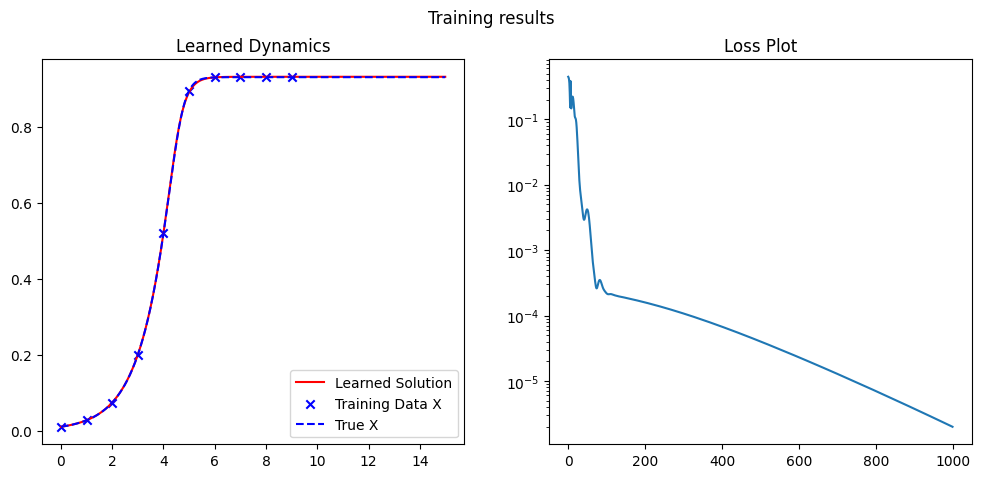

In [222]:
T_MAX = 15
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_pred = odeint(my_growth, 
                x0_torch,
                T_torch := torch.arange(0, T_MAX, 0.01)
                )

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))

T = sol.t
X = sol.y[0]

func = axes[0]

func.plot(T_torch, x_pred.detach().numpy(), label="Learned Solution", color='red')
func.scatter(T_train, X_train, label="Training Data X", color='blue', marker='x')
func.plot(T, X, "--", label="True X", color='blue')
func.legend()
func.set_title("Learned Dynamics")

loss = axes[1]

loss.semilogy(losses)
loss.set_title("Loss Plot")

plt.suptitle("Training results")

plt.show()

In [223]:
X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T_train, X_train)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=50000, verbose=True)
)

model.fit(X_train, T_train, feature_names=['x'], x_dot=X_dot.detach().numpy())


c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.5955e-02 ... 0.0000e+00 ... 3.0000e-02 ... 6.5955e-02
         1 ... 1.8359e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.8359e-02
         2 ... 1.3405e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.3405e-02
         3 ... 9.8297e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.9830e-02
         4 ... 7.2338e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.7234e-02
         5 ... 5.3489e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5349e-02
         6 ... 3.9800e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.3980e-02
         7 ... 2.9858e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.2986e-02
         8 ... 2.2635e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.2264e-02
         9 ... 1.7387e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.1739e-02
        10 ... 1.3571e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.1357e-02
        11 ... 1.0796e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.1080e-02
        12 ... 8.7763e-04 ... 0.0000e+00 ... 3.

,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 5.5506e-02 ... 0.0000e+00 ... 3.0000e-02 ... 8.5506e-02
         1 ... 1.2610e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.2610e-02
         2 ... 6.8075e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.6808e-02
         3 ... 5.5683e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5568e-02
         4 ... 4.9587e-03 ... 8.9764e-03 ... 3.0000e-02 ... 4.3935e-02
         5 ... 3.0626e-03 ... 1.7133e-04 ... 3.0000e-02 ... 3.3234e-02
         6 ... 2.6668e-03 ... 8.7162e-06 ... 3.0000e-02 ... 3.2676e-02
         7 ... 2.5230e-03 ... 3.8897e-05 ... 3.0000e-02 ... 3.2562e-02
         8 ... 2.4360e-03 ... 4.6836e-05 ... 3.0000e-02 ... 3.2483e-02
         9 ... 2.3655e-03 ... 4.6805e-05 ... 3.0000e-02 ... 3.2412e-02
        10 ... 2.3025e-03 ... 4.4730e-05 ... 3.0000e-02 ... 3.2347e-02
        11 ... 2.2447e-03 ... 4.2205e-05 ... 3.0000e-02 ... 3.2287e-02
        12 ... 2.1914e-03 ... 3.9666e-05 ... 3.

,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


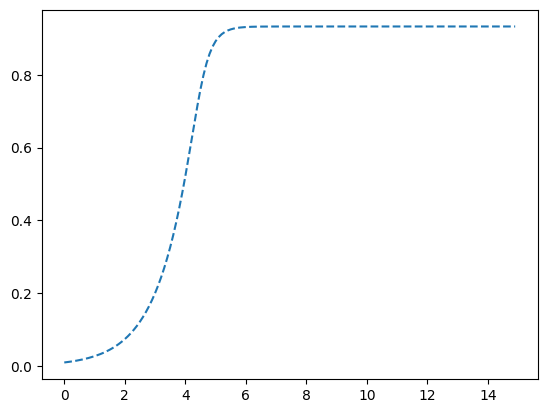

In [224]:
# Now... train SINDy with the new derivatives

# recover data
bigger_t_train = torch.arange(0, T_MAX, 0.1)


sol = odeint(my_growth, 
                    torch.tensor([x0], dtype=torch.float32, requires_grad=True),
                    bigger_t_train,
                    )

data = sol.detach().numpy()

T = bigger_t_train.detach().numpy()
X = data

plt.plot(T, X, "--", label="True X")


# we use lots of data instead
T_train = T
X_train = X

X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T, X)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))


model_lots = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=True),
)

model_lots.fit(X_train, T_train, feature_names=['x'], x_dot=X_dot.detach().numpy())

In [225]:
model.print()
model_lots.print()

(x)' =  1.015 x + -0.550 x^4 + -0.754 x^5
(x)' =  0.992 x + -0.130 x^4 + -1.175 x^5


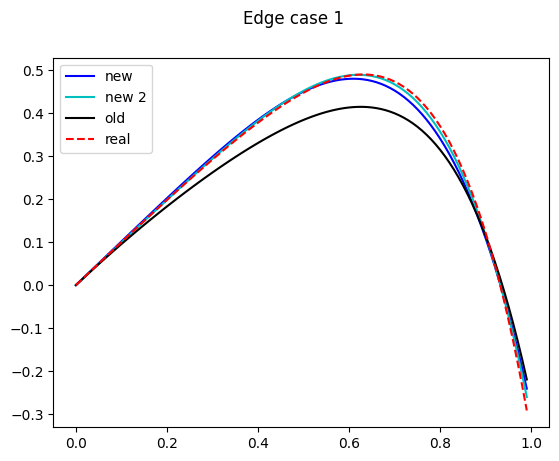

In [ ]:
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model), "b", label="new")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_lots), "c", label="new 2")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_old), "k", label="old")
plt.plot(np.arange(0, 1, 0.01), poly_real(np.arange(0, 1, 0.01), k+1), "r--", label="real")

plt.suptitle("Edge case 1")

plt.legend()

plt.show()



In [230]:
def poly_diff1(x):
    return (poly_sindy(x, k+1, model)-poly_real(x, k+1))**2

def poly_diff2(x):
    return (poly_sindy(x, k+1, model_old)-poly_real(x, k+1))**2

def poly_diff3(x):
    return (poly_sindy(x, k+1, model_old)-poly_real(x, k+1))**2

print("L2 Erorr in [0,1] before data augmentation with UDEs:\t", quad(poly_diff2, 0, 1),"\nL2 Error after:\t",
quad(poly_diff1, 0, 1),"\nL2 Error after (with more data):\t", quad(poly_diff3, 0,1))

L2 Erorr in [0,1] before data augmentation with UDEs:	 (0.002318303812376467, 2.5738342705766327e-17) 
L2 Error after:	 (0.00024004576486512806, 2.665043351170216e-18) 
L2 Error after (with more data):	 (0.002318303812376467, 2.5738342705766327e-17)


### x_0 = 2

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]


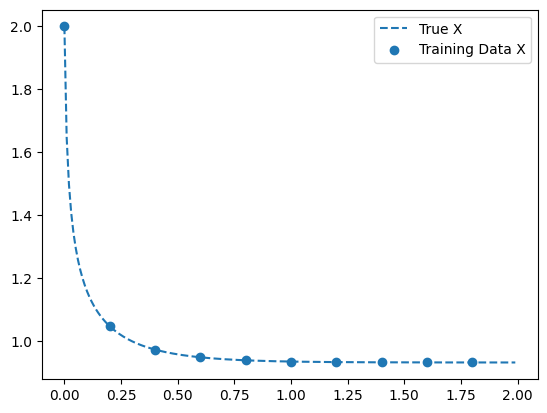

In [58]:
T_MAX = 2

x0 = 2

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")


T_train = T[::20]
X_train = X[::20]


print(T_train)
plt.scatter(T_train, X_train, label="Training Data X")


plt.legend()

plt.show()

In [59]:
model_old = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=5000, verbose=True)
)
model_old.fit(X_train, T_train, feature_names=['x'])

model_old.print()

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 4.2461e+00 ... 0.0000e+00 ... 3.0000e-02 ... 4.2761e+00
         1 ... 3.9271e+00 ... 0.0000e+00 ... 3.0000e-02 ... 3.9571e+00
         2 ... 3.6518e+00 ... 0.0000e+00 ... 3.0000e-02 ... 3.6818e+00
         3 ... 3.3973e+00 ... 0.0000e+00 ... 3.0000e-02 ... 3.4273e+00
         4 ... 3.1620e+00 ... 0.0000e+00 ... 3.0000e-02 ... 3.1920e+00
         5 ... 2.9445e+00 ... 9.5101e-03 ... 3.0000e-02 ... 2.9840e+00
         6 ... 2.7356e+00 ... 2.6915e-04 ... 3.0000e-02 ... 2.7659e+00
         7 ... 2.5515e+00 ... 1.9222e-03 ... 3.0000e-02 ... 2.5834e+00
         8 ... 2.3834e+00 ... 2.5778e-03 ... 3.0000e-02 ... 2.4160e+00
         9 ... 2.2283e+00 ... 2.6525e-03 ... 3.0000e-02 ... 2.2610e+00
        10 ... 2.0849e+00 ... 2.5395e-03 ... 3.0000e-02 ... 2.1175e+00
        11 ... 1.9521e+00 ... 2.3789e-03 ... 3.0000e-02 ... 1.9845e+00
        12 ... 1.8292e+00 ... 2.2134e-03 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 5000 iterations.
  warnings.warn(


In [60]:
# Step 2. Create UDE of type x NN(x) and make it learn...

class ude_generalised_growth(nn.Module):
    def __init__(self, rho0):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        ) 

    def forward(self, t, x):
        return x * (self.net(x))

In [61]:
my_growth = ude_generalised_growth(rho0)

lr = 0.005
optimizer = torch.optim.Adam(my_growth.parameters(), lr=lr)
rtol = 1e-7

n_epochs = 1000

t_train_torch = torch.tensor(T_train, dtype=torch.float32)
x0_torch = torch.tensor([x0], dtype=torch.float32, requires_grad=True)
x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)

losses = []

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = odeint(my_growth, 
                    x0_torch,
                    t_train_torch,
                    rtol=1e-7, atol=1e-9
                    )
    
    # Compute loss at training points

    loss = torch.mean(torch.pow(x_pred-x_train_torch, 2))
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        losses.append(loss.detach())
        print(f"{EPOCH}\t{loss.item()}")




0	0.406389057636261
1	0.21012750267982483
2	0.13362714648246765
3	0.11407853662967682
4	0.11857036501169205
5	0.12938091158866882
6	0.13846346735954285
7	0.14339640736579895
8	0.14414921402931213
9	0.14147821068763733
10	0.13637326657772064
11	0.12992973625659943
12	0.12333314120769501
13	0.11782188713550568
14	0.11453374475240707
15	0.11415330320596695
16	0.1163829118013382
17	0.11963284015655518
18	0.12173967063426971
19	0.1214839369058609
20	0.11920185387134552
21	0.11610998958349228
22	0.11337270587682724
23	0.1116081029176712
24	0.11087118089199066
25	0.11087091267108917
26	0.11120013892650604
27	0.11149201542139053
28	0.11149324476718903
29	0.11107858270406723
30	0.11024413257837296
31	0.10907883942127228
32	0.10773930698633194
33	0.10640827566385269
34	0.10525290668010712
35	0.1043776422739029
36	0.10377975553274155
37	0.1033385768532753
38	0.10284576565027237
39	0.10209454596042633
40	0.10097672045230865
41	0.09952794760465622
42	0.09789861738681793
43	0.09625481069087982
44	0.

In [62]:
torch.save(my_growth.state_dict(), "./models_weights/growth_ude_xbig.dinomeng")

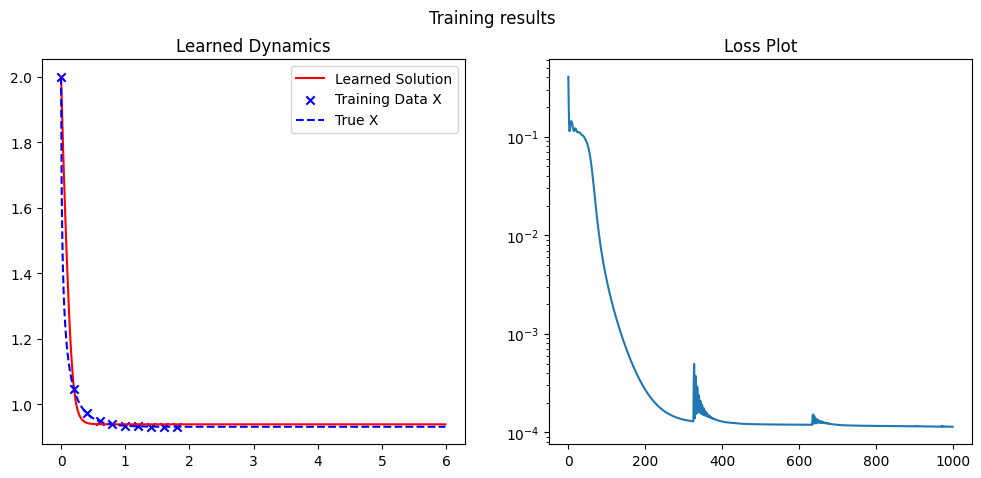

In [63]:
T_MAX = 6
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_pred = odeint(my_growth, 
                x0_torch,
                T_torch := torch.arange(0, T_MAX, 0.01)
                )

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))

T = sol.t
X = sol.y[0]

func = axes[0]

func.plot(T_torch, x_pred.detach().numpy(), label="Learned Solution", color='red')
func.scatter(T_train, X_train, label="Training Data X", color='blue', marker='x')
func.plot(T, X, "--", label="True X", color='blue')
func.legend()
func.set_title("Learned Dynamics")

loss = axes[1]

loss.semilogy(losses)
loss.set_title("Loss Plot")

plt.suptitle("Training results")

plt.show()

In [ ]:
X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T_train, X_train)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=True)
)

model.fit(X_train, T_train, feature_names=['x'], x_dot=X_dot.detach().numpy())


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.0781e+00 ... 1.8885e-05 ... 3.0000e-02 ... 3.1081e+00
         1 ... 1.3565e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.3865e+00
         2 ... 1.0633e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.0933e+00
         3 ... 1.0127e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.0427e+00
         4 ... 1.0032e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.0332e+00
         5 ... 1.0005e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.0305e+00
         6 ... 9.9893e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0289e+00
         7 ... 9.9747e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0275e+00
         8 ... 9.9603e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0260e+00
         9 ... 9.9458e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0246e+00
        10 ... 9.9314e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0231e+00
        11 ... 9.9169e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0217e+00
        12 ... 9.9025e-01 ... 0.0000e+00 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.0781e+00 ... 1.8885e-05 ... 3.0000e-02 ... 3.1081e+00
         1 ... 1.3565e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.3865e+00
         2 ... 1.0633e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.0933e+00
         3 ... 1.0127e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.0427e+00
         4 ... 1.0032e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.0332e+00
         5 ... 1.0005e+00 ... 0.0000e+00 ... 3.0000e-02 ... 1.0305e+00
         6 ... 9.9893e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0289e+00
         7 ... 9.9747e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0275e+00
         8 ... 9.9603e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0260e+00
         9 ... 9.9458e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0246e+00
        10 ... 9.9314e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0231e+00
        11 ... 9.9169e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.0217e+00
        12 ... 9.9025e-01 ... 0.0000e+00 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


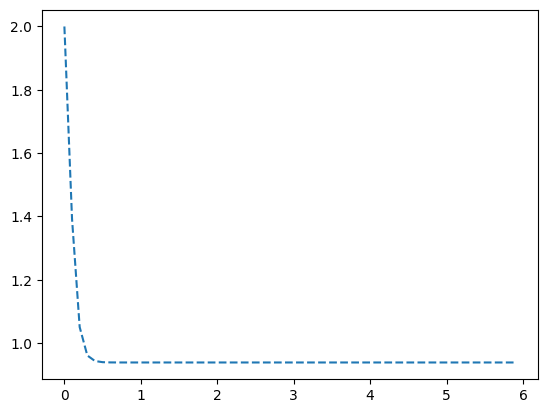

In [73]:
# Now... train SINDy with the new derivatives

# recover data
bigger_t_train = torch.arange(0, T_MAX, 0.1)


sol = odeint(my_growth, 
                    torch.tensor([x0], dtype=torch.float32, requires_grad=True),
                    bigger_t_train,
                    )

data = sol.detach().numpy()

T = bigger_t_train.detach().numpy()
X = data

plt.plot(T, X, "--", label="True X")


# we use lots of data instead
T_train = T
X_train = X

X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T, X)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))


model_lots = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=True),
)

model_lots.fit(X_train, T_train, feature_names=['x'], x_dot=X_dot.detach().numpy())

In [74]:
model.print()
model_lots.print()

(x)' =  7.491 x + -7.262 x^3 + -2.317 x^4 +  1.138 x^6
(x)' =  4.214 x + -5.153 x^3 +  0.373 x^6


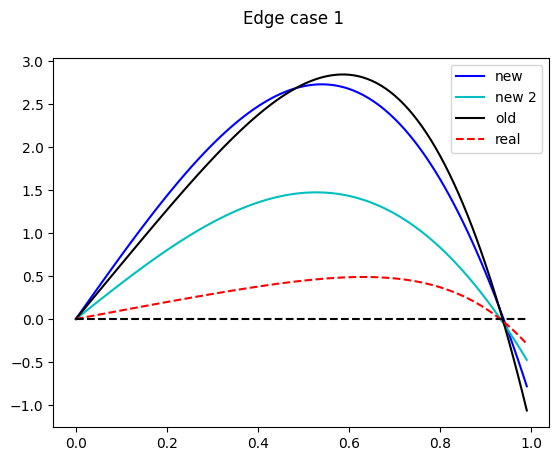

L2 Erorr in [0,1] before data augmentation with UDEs:	 (2.60279739636364, 2.889685597877323e-14) 
L2 Error after:	 (2.4592984925927874, 2.7303698109024526e-14) 
L2 Error after (with more data):	 (0.48687500074081297, 5.405398359368407e-15)


In [75]:
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model), "b", label="new")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_lots), "c", label="new 2")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_old), "k", label="old")
plt.plot(np.arange(0, 1, 0.01), poly_real(np.arange(0, 1, 0.01), k+1), "r--", label="real")

plt.plot(np.arange(0, 1, 0.01), np.zeros_like(np.arange(0, 1, 0.01)), "k--")

plt.suptitle("Edge case 1")

plt.legend()

plt.show()

def poly_diff1(x):
    return (poly_sindy(x, k+1, model)-poly_real(x, k+1))**2

def poly_diff2(x):
    return (poly_sindy(x, k+1, model_old)-poly_real(x, k+1))**2

def poly_diff3(x):
    return (poly_sindy(x, k+1, model_lots)-poly_real(x, k+1))**2

print("L2 Erorr in [0,1] before data augmentation with UDEs:\t", quad(poly_diff2, 0, 1),"\nL2 Error after:\t",
quad(poly_diff1, 0, 1),"\nL2 Error after (with more data):\t", quad(poly_diff3, 0,1))

### Variation of the initial state $x_0 \in [0.01, 2]$
Let's generalize the previous code, being particularly careful of choosing T_MAX for each initial state as convergence times can vary

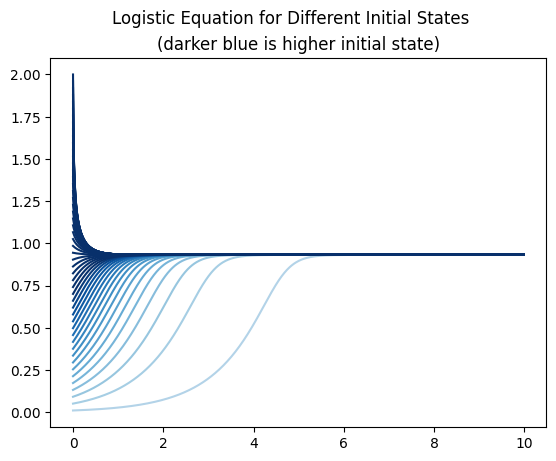

In [121]:
x0_space = np.linspace(0.01, 2, 50)


cmap = mpl.colormaps["Blues"]

colors = cmap(x0_space + 0.3)

T_MAX = 10.


for i, x0 in enumerate(x0_space):
    sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                    (0,T_MAX, 0.01))
    data = sol.y

    T = sol.t
    X = data[0]

    plt.plot(T, X, color=colors[i])

plt.suptitle("Logistic Equation for Different Initial States")
plt.title("(darker blue is higher initial state)")
plt.show()